# Multi-Vector Search: A Late Interaction Field Guide

A hands-on companion to the lecture of the same name! Everything is meant to run on a laptop CPU: the first run downloads three models (17M, 47M and 256M parameters), a 50-query code-retrieval sample and four public documents.

**Prerequisites.** Python 3.12, internet access on the first run, and 8 GB RAM recommended. If you want to experiment with a state-of-the-art parser, you will need a `LIGHTON_API_KEY`: get one at https://console.lighton.ai/, and check the docs if need be https://developers.lighton.ai/.
Additionally, you may want to set a `HF_TOKEN` (get one on https://huggingface.co/) to allow for faster downloads.

**By the end you will be able to:**
1. implement and interpret MaxSim;
2. compare lexical, single-vector and late-interaction retrieval on code;
3. separate *finding a page* from *preserving its answer-bearing layout* in visual documents;

**Roadmap.** MaxSim operator → code field case → multimodal field case.

In [ ]:
# If running outside of the AI-Powered Search Docker container, uncomment and install these dependencies
# %pip install -q "numpy<3" "torch>=2.2,<2.12" "transformers==5.3.0" "sentence-transformers==5.3.0" "colpali-engine==0.3.17" "mistral-common>=1.11.5,<2" "peft>=0.18,<0.20" rank-bm25 datasets einops seaborn pymupdf pandas matplotlib ipywidgets pyarrow pillow huggingface-hub tqdm requests
# %pip install -q --no-deps "pylate==1.6.0"

In [2]:
import glob, importlib.metadata as metadata, html, io, math, os, re, time, urllib.request
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import datasets, fitz, ipywidgets as widgets, matplotlib.pyplot as plt, numpy as np, pandas as pd, requests, torch, transformers
from colpali_engine.models import ColIdefics3, ColIdefics3Processor
from datasets import load_dataset
from huggingface_hub import hf_hub_download, snapshot_download
from IPython.display import HTML, clear_output, display
from matplotlib import font_manager as fm
from peft import PeftModel
from PIL import Image
from pylate import models
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

datasets.disable_progress_bars()
transformers.utils.logging.disable_progress_bar()
transformers.utils.logging.set_verbosity_error()
torch.set_num_threads(max(1, (os.cpu_count() or 4) - 2))

# Pretty plot settings
C = {"edge": "#e2e8f0", "grid": "#eef2f6", "panel": "#f8fafc", "baseline": "#cbd5e1",
     "text": "#334155", "muted": "#64748b", "faint": "#94a3b8", "ink": "#0f172b",
     "signal_bg": "#e8f7fc", "cyan": "#0b7fa8", "cyan_fill": "#1acff6", "blue": "#2563eb"}

for font_path in glob.glob(str(Path.home() / "Library/Fonts/*.ttf")):
    try:
        fm.fontManager.addfont(font_path)
    except Exception:
        pass
available = {font.name for font in fm.fontManager.ttflist}
SANS = "IBM Plex Sans" if "IBM Plex Sans" in available else "DejaVu Sans"
MONO = "IBM Plex Mono" if "IBM Plex Mono" in available else "DejaVu Sans Mono"
MONOKW = {"fontfamily": MONO}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.family": SANS, "font.size": 10, "axes.titlesize": 10,
    "axes.edgecolor": C["edge"], "axes.labelcolor": C["text"], "text.color": C["text"],
    "xtick.color": C["muted"], "ytick.color": C["muted"], "grid.color": C["grid"], "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
})
%config InlineBackend.figure_format = "retina"

versions = ["numpy", "torch", "transformers", "pylate", "colpali-engine", "datasets"]
print(" | ".join(f"{name} {metadata.version(name)}" for name in versions))
print("CPU threads", torch.get_num_threads())

numpy 1.26.4 | torch 2.11.0 | transformers 5.3.0 | pylate 1.6.0 | colpali-engine 0.3.17 | datasets 3.3.2
CPU threads 10


## 0 · The operator: MaxSim

Late interaction keeps **one vector per token** instead of one pooled vector per document. At query time, each query token looks across all document tokens and keeps its single best match, and the score is the sum of those best matches:

$$\mathrm{MaxSim}(Q, D) \;=\; \sum_{i \in Q} \, \max_{j \in D} \; \mathbf{q}_i \cdot \mathbf{d}_j$$

The `max` is the key move: a rare, high-signal clue (a status code, a function name) keeps its full weight instead of being averaged away with every irrelevant token.

The next three cells separate the pieces: the token vectors, the full interaction matrix, and the final calculation.

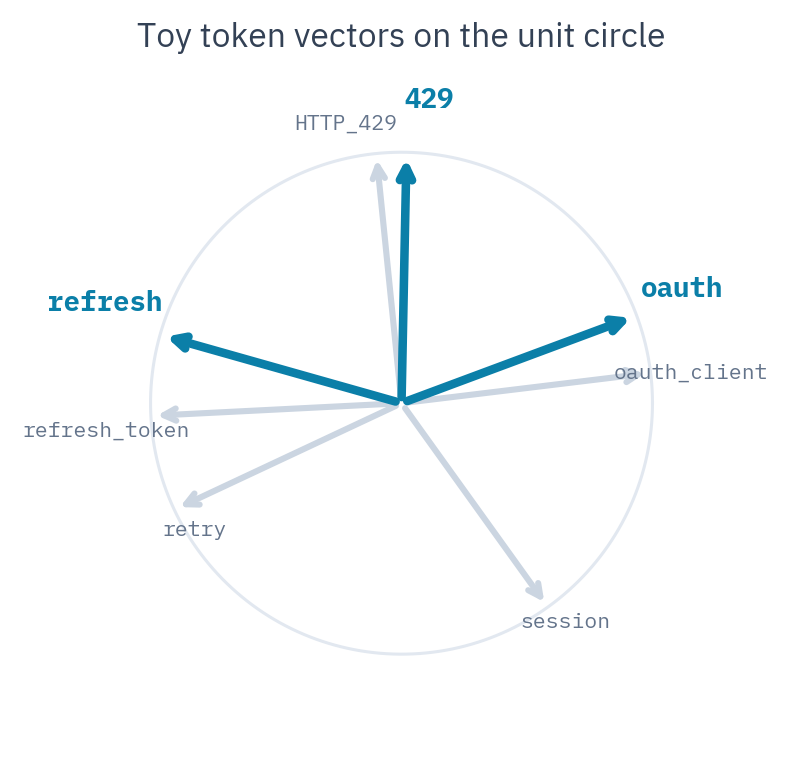

In [3]:
def maxsim(Q, D):
    # Q: (query tokens, dim), D: (document tokens, dim), rows L2-normalised
    return (Q @ D.T).max(axis=1).sum()

# These are just toy tokens! We've defined them so they are roughly where
# we would expect w.r.t. each other :)
q_tokens = ["oauth", "429", "refresh"]
d_tokens = ["session", "oauth_client", "retry", "HTTP_429", "refresh_token"]

Q = np.array([[0.86, 0.32], [0.02, 1.00], [-0.92, 0.26]])
D = np.array([[0.56, -0.78], [0.99, 0.12], [-0.32, -0.15], [-0.10, 0.99], [-0.99, -0.05]])


Q = Q / np.linalg.norm(Q, axis=1, keepdims=True)   # unit vectors: dot product = cosine
D = D / np.linalg.norm(D, axis=1, keepdims=True)

# Let's visualize things
fig, ax = plt.subplots(figsize=(6, 4))

theta = np.linspace(0, 2 * np.pi, 240)
ax.plot(np.cos(theta), np.sin(theta), color=C["edge"], lw=1)

# Offsets just for plotting
doc_offsets = {"session": (0.07, -0.08), "oauth_client": (0.16, -0.02), "retry": (0.08, -0.10),
               "HTTP_429": (-0.12, 0.10), "refresh_token": (-0.18, -0.08)}
query_offsets = {"oauth": (0.18, 0.08), "429": (0.09, 0.18), "refresh": (-0.22, 0.10)}

for vec, token in zip(D, d_tokens):
    ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=C["baseline"], lw=2))
    dx, dy = doc_offsets[token]
    ax.text(vec[0] + dx, vec[1] + dy, token, fontsize=7, color=C["muted"], ha="center", **MONOKW)
for vec, token in zip(Q, q_tokens):
    ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=C["cyan"], lw=2.8))
    dx, dy = query_offsets[token]
    ax.text(vec[0] + dx, vec[1] + dy, token, fontsize=9, color=C["cyan"], ha="center", fontweight="bold", **MONOKW)

ax.set_xlim(-1.45, 1.45)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect("equal")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Toy token vectors on the unit circle", fontsize=11)
plt.show()

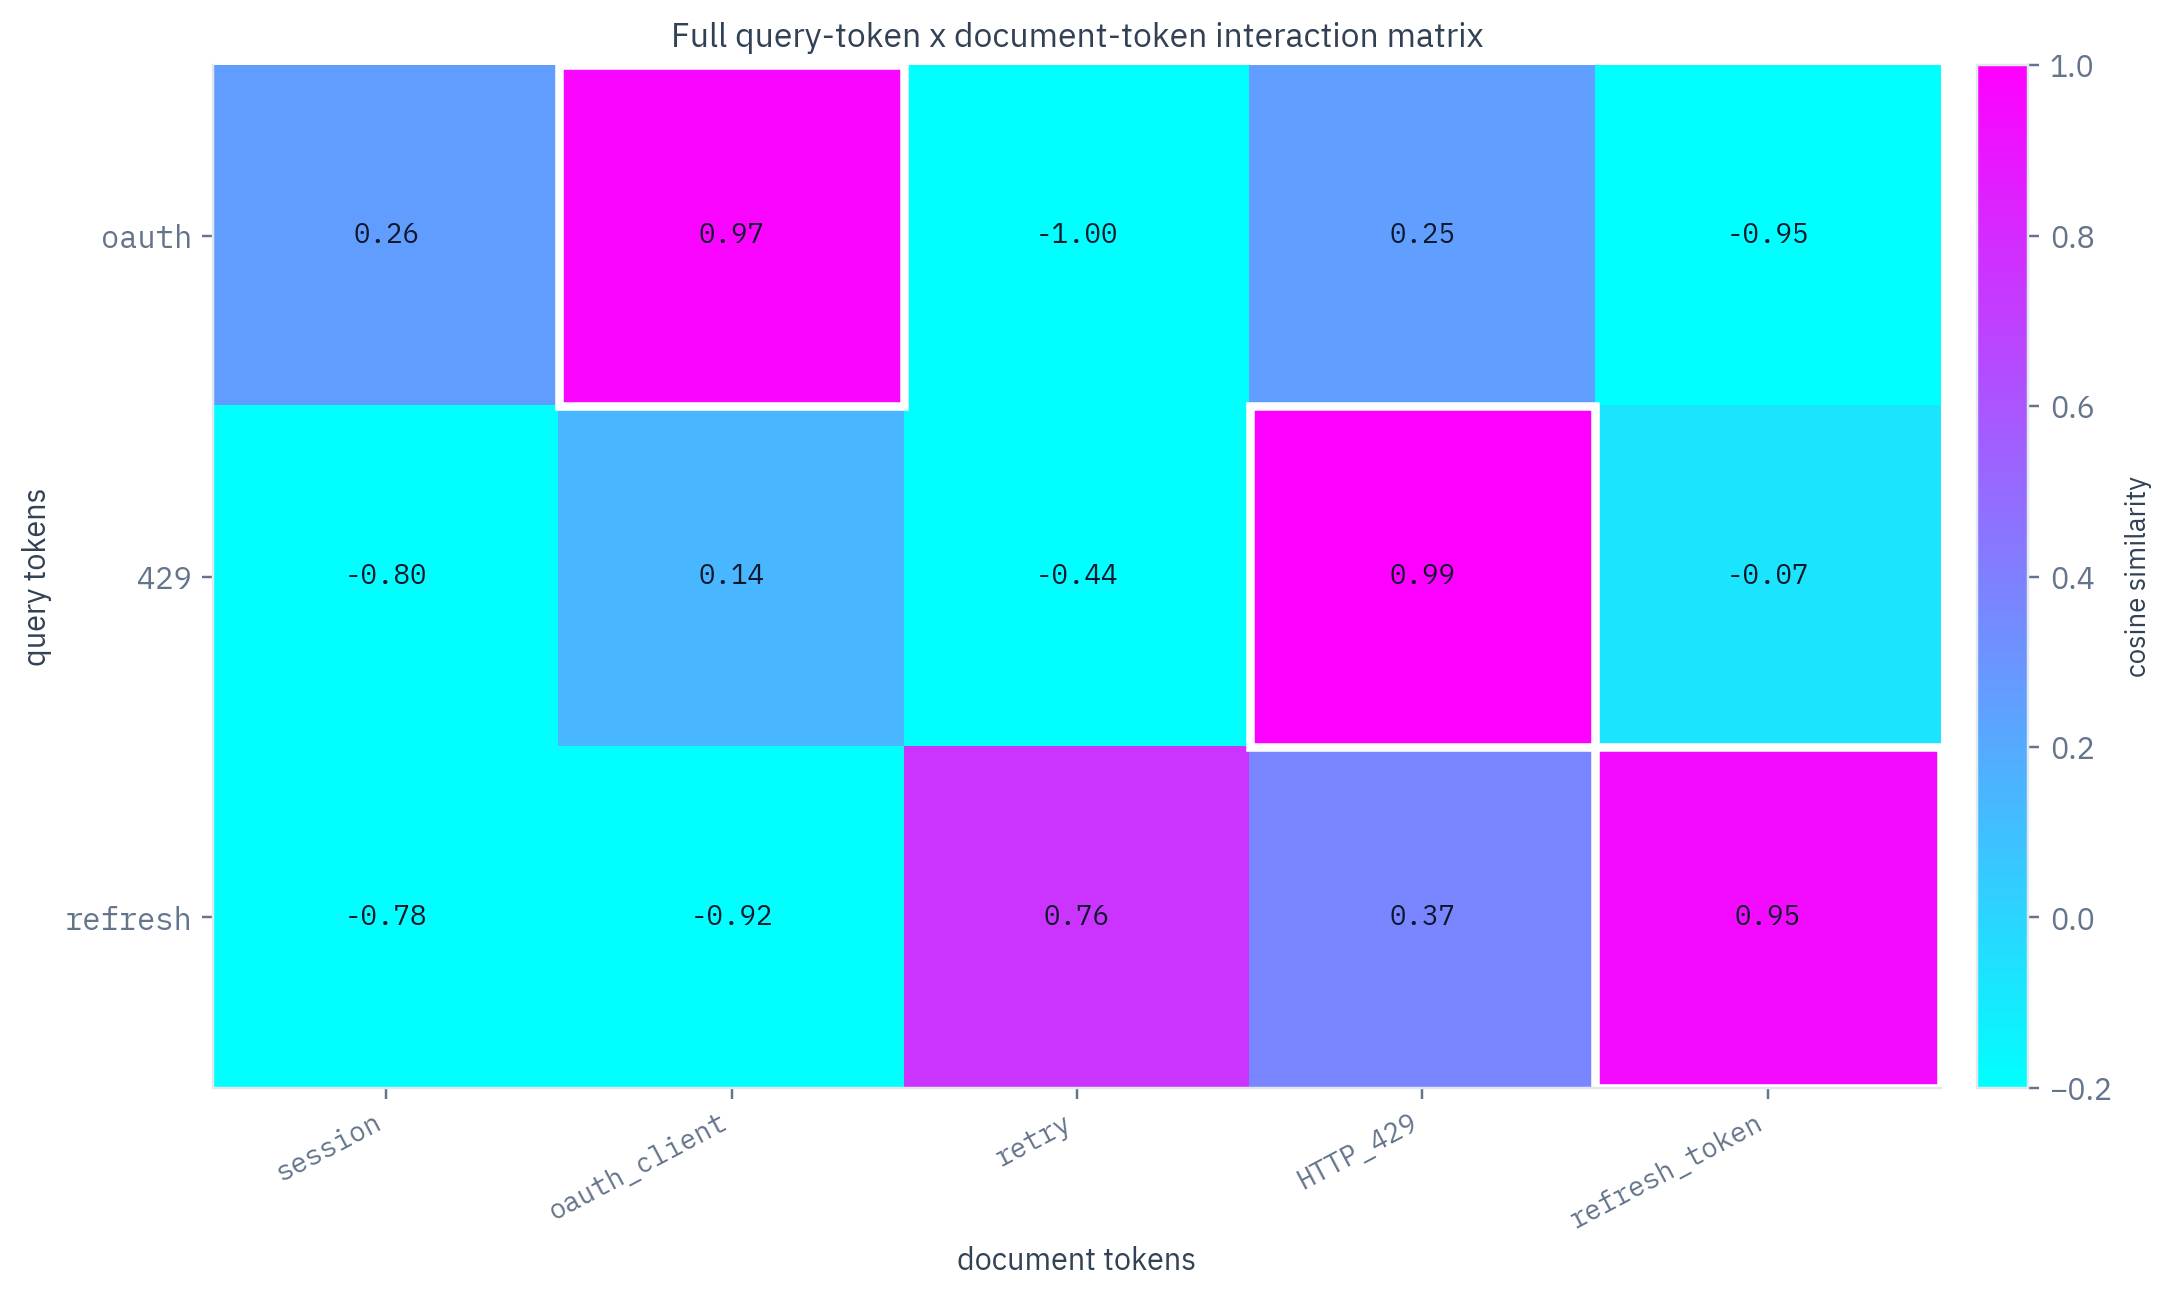

In [4]:
S = Q @ D.T                 # every query token against every document token
picks = S.argmax(axis=1)    # the max each query token keeps

fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(S, cmap="cool", vmin=-0.2, vmax=1.0, aspect="auto")
ax.grid(False)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=9, color=C["ink"], **MONOKW)
    ax.add_patch(plt.Rectangle((picks[i] - 0.5, i - 0.5), 1, 1, fill=False, ec="white", lw=2.8))

ax.set_xticks(range(len(d_tokens)))
ax.set_xticklabels(d_tokens, rotation=28, ha="right", fontsize=9, **MONOKW)
ax.set_yticks(range(len(q_tokens)))
ax.set_yticklabels(q_tokens, fontsize=10, **MONOKW)
ax.set_xlabel("document tokens")
ax.set_ylabel("query tokens")
ax.set_title("Full query-token x document-token interaction matrix", fontsize=11)
fig.colorbar(image, ax=ax, fraction=0.04, pad=0.02).set_label("cosine similarity", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
best = S.max(axis=1)
calculation = pd.DataFrame({
    "query token": q_tokens,
    "best document token": [d_tokens[j] for j in picks],
    "best similarity": best,
})
display(calculation.round(3))
print("MaxSim(Q, D) = " + " + ".join(f"{v:.2f}" for v in best) + f" = {maxsim(Q, D):.2f}")

,query token,best document token,best similarity
0,oauth,oauth_client,0.972
1,429,HTTP_429,0.993
2,refresh,refresh_token,0.947


MaxSim(Q, D) = 0.97 + 0.99 + 0.95 = 2.91


There we have it, the MaxSim!
Quick comment on what we can see from the full interaction matrix:
- `refresh` matches best with `refresh_token`, but also quite strongly with `retry`. Yet, that second match does not contribute to the score, due to the way the operator works.
- `429` contributes a lot to the score due to its match with `HTTP_429`, while matching really poorly with the rest of the document tokens: this is what we were discussing in the lecture by the `Max` in `MaxSim` forces us to keep strong and rare matches! A `Mean` would drown that out.

As an illustration, let's try to see how our contributions would switch if we used a mean similarity for example:

,query token,MaxSim contribution,MeanSim contribution
0,oauth,0.972,-0.092
1,429,0.993,-0.036
2,refresh,0.947,0.073


MaxSim total  = 2.91
MeanSim total = -0.06


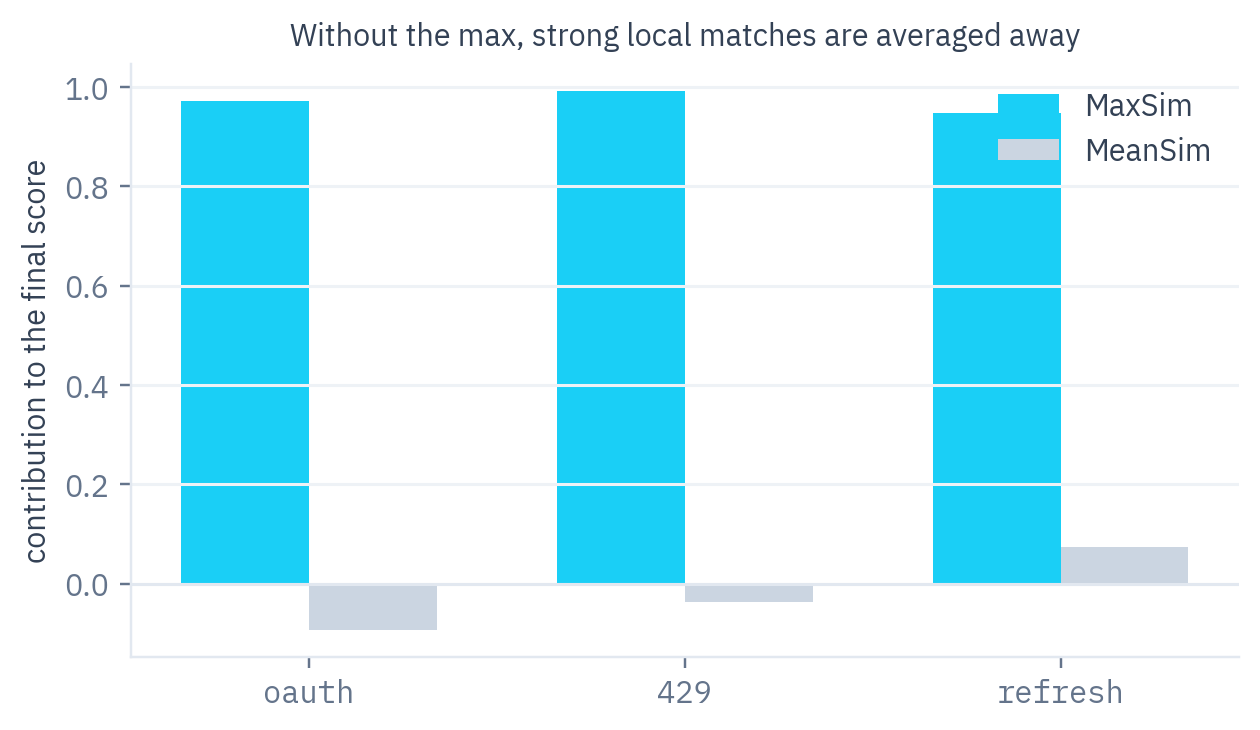

In [6]:
# Counterfactual: replace MaxSim's max with a mean over document tokens
max_contributions = S.max(axis=1)
mean_contributions = S.mean(axis=1)

comparison = pd.DataFrame({
    "query token": q_tokens,
    "MaxSim contribution": max_contributions,
    "MeanSim contribution": mean_contributions,
})

display(comparison.round(3))

print(f"MaxSim total  = {max_contributions.sum():.2f}")
print(f"MeanSim total = {mean_contributions.sum():.2f}")

x = np.arange(len(q_tokens))
width = 0.34

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(
    x - width / 2,
    max_contributions,
    width,
    label="MaxSim",
    color=C["cyan_fill"],
)
ax.bar(
    x + width / 2,
    mean_contributions,
    width,
    label="MeanSim",
    color=C["baseline"],
)

ax.axhline(0, color=C["edge"], linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(q_tokens, **MONOKW)
ax.set_ylabel("contribution to the final score")
ax.set_title("Without the max, strong local matches are averaged away")
ax.legend(frameon=False)
plt.show()

Without the maximum, each query token is influenced by every document token. The strong `429` → `HTTP_429` match is therefore averaged together with several irrelevant or opposing interactions, which dilutes the rare exact signal MaxSim was designed to preserve :(.
Anyways, let's move away from toy tokens now.

## 1 · Field case: code retrieval

Why does a frontier coding agent still reach for `grep`?

Beyond boring, infra reasons: because lexical matching is extremely strong for code, and **granularity** is non-negotiable: exact symbols, paths and error strings must match verbatim. But grep breaks the moment the user says `auth` and the code says `credentials` -> this is the vocabulary mismatch problem. We want exact-ish granularity **and** soft semantic matching, and that seam is where late interaction sits!

Below, the same query goes through three retrieval shapes:

- **BM25**, the lexical baseline;
- `ibm-granite/granite-embedding-small-english-r2` (47M), one 384-dim vector per document; a smallish dense model that is  competitive on code;
- `lightonai/LateOn-Code-edge` (17M), almost 3x as small, one 48-dim vector per token, scored with MaxSim.

In [7]:
t = time.time()
late = models.ColBERT(
    model_name_or_path="lightonai/LateOn-Code-edge",
)
dense = SentenceTransformer(
    "ibm-granite/granite-embedding-small-english-r2",
)
print(
    f"loaded code models in {time.time() - t:.0f}s | "
    f"LateOn 48-dim/token | granite {dense.get_sentence_embedding_dimension()}-dim/doc"
)


loaded code models in 5s | LateOn 48-dim/token | granite 384-dim/doc


### 1a · One query, three retrieval shapes

Let's consider the query `how to retry a rate-limited OAuth sign-in`.
We build a toy corpus with two snippets which genuinely answer the query:
- one phrased in pure **synonyms** (`reauthenticate`: *too many requests*, *credential exchange*, not one literal query word)
- one with the **literal tokens** (`refresh_oauth_token`: `retry`, `oauth`, `429`, `rate limited`).
The rest of the corpus is made of three unrelated functions.

In [8]:
query = "how to retry a rate-limited OAuth sign-in"
corpus = {
"reauthenticate": '''def reauthenticate(client):
    # the identity provider responded that there were too many requests;
    # pause, then attempt the credential exchange once more
    for attempt in range(5):
        resp = client.post("/session")
        if resp.throttled:
            backoff(); continue
        return resp.credentials''',
"refresh_oauth_token": '''def refresh_oauth_token(self):
    for retry in range(5):
        r = self._post("/oauth/token")
        if r.status_code == 429:          # rate limited
            sleep(backoff); continue
    return r.json()["access_token"]''',
"connect_db": '''def connect_db(dsn, pool_size=10):
    pool = ConnectionPool(dsn, max_size=pool_size)
    return pool.acquire()''',
"parse_response": '''def parse_response(resp):
    data = resp.json()
    return {k: v for k, v in data.items() if v is not None}''',
"configure_logging": '''def configure_logging(level="INFO"):
    logging.basicConfig(level=level, format="%(asctime)s %(message)s")''',
}
GOLD = ("reauthenticate", "refresh_oauth_token")
labels = [name.split(" · ")[0] for name in corpus]

cards = []
for name, src in corpus.items():
    is_answer = name in GOLD
    tag, col, bg = ("expected answer", C["cyan"], C["signal_bg"]) if is_answer else ("distractor", C["faint"], C["panel"])
    cards.append(
        f'<div style="border:1px solid {C["edge"]};border-left:4px solid {col};background:{bg};'
        f'border-radius:6px;padding:7px 12px;margin:6px 0;">'
        f'<div style="font:600 11px {SANS},sans-serif;color:{col};text-transform:uppercase;'
        f'letter-spacing:.05em;">{tag} &nbsp;·&nbsp; {html.escape(name.split(" · ")[0])}</div>'
        f'<pre style="margin:5px 0 0;font:12px/1.45 {MONO},monospace;color:{C["ink"]};'
        f'white-space:pre-wrap;">{html.escape(src)}</pre></div>'
    )
banner = (
    f'<div style="font:600 14px {SANS},sans-serif;color:{C["ink"]};margin:2px 0 6px;">query &nbsp;'
    f'<span style="color:{C["cyan"]};">{html.escape(query)}</span></div>'
)
display(HTML(banner + "".join(cards)))

In [9]:
docs = list(corpus.values())

# the three scorers, side by side
# BM25 requires a tokenizer, let's pick a simple one.
def toks(text):
    return re.findall(r"[a-z0-9_]+", text.lower())
bm25_scores = BM25Okapi([toks(doc) for doc in docs]).get_scores(toks(query))

# Dense
dense_query = dense.encode([query], normalize_embeddings=True)[0]
dense_scores = dense.encode(docs, normalize_embeddings=True) @ dense_query

# Late interaction
# Note that LateOn-code treats docs and queries asymmetrically,
# so we need to specify `is_query`.
# This type of information can usually be found in Hugging Face model cards!
late_query = np.asarray(late.encode([query], is_query=True)[0])
late_scores = np.array([maxsim(late_query, np.asarray(d)) for d in late.encode(docs, is_query=False)])

scores = {"BM25 (lexical)": bm25_scores, "granite (dense)": dense_scores, "LateOn (multi-vector)": late_scores}
ranks = pd.DataFrame({method: (-np.asarray(v)).argsort().argsort() + 1 for method, v in scores.items()}, index=labels)
print("rank position per method (1 = top hit):")
print()
display(ranks)


rank position per method (1 = top hit):



,BM25 (lexical),granite (dense),LateOn (multi-vector)
reauthenticate,3,2,2
refresh_oauth_token,1,1,1
connect_db,4,3,4
parse_response,2,4,5
configure_logging,5,5,3


What we see:
1. BM25 loses the synonym answer among the distractors: it shares no surface tokens with the query. This is expected, vocabulary mismatch!
2. The dense and late-interaction models rank BOTH answers above every distractor.

### 1b · What late interaction actually matched

Beyond scoring, MaxSim gives us a nice interpretability bonus: for every code token we can read how strongly the query reached it (its best similarity to any query token) and colour that back onto the source.
The **literal** answer lights up sharply on `oauth`, `retry` and `rate limited`; the **synonym** answer matches more softly and diffusely, with no single token dominating. That token-level readout is discarded with single vector pooling.

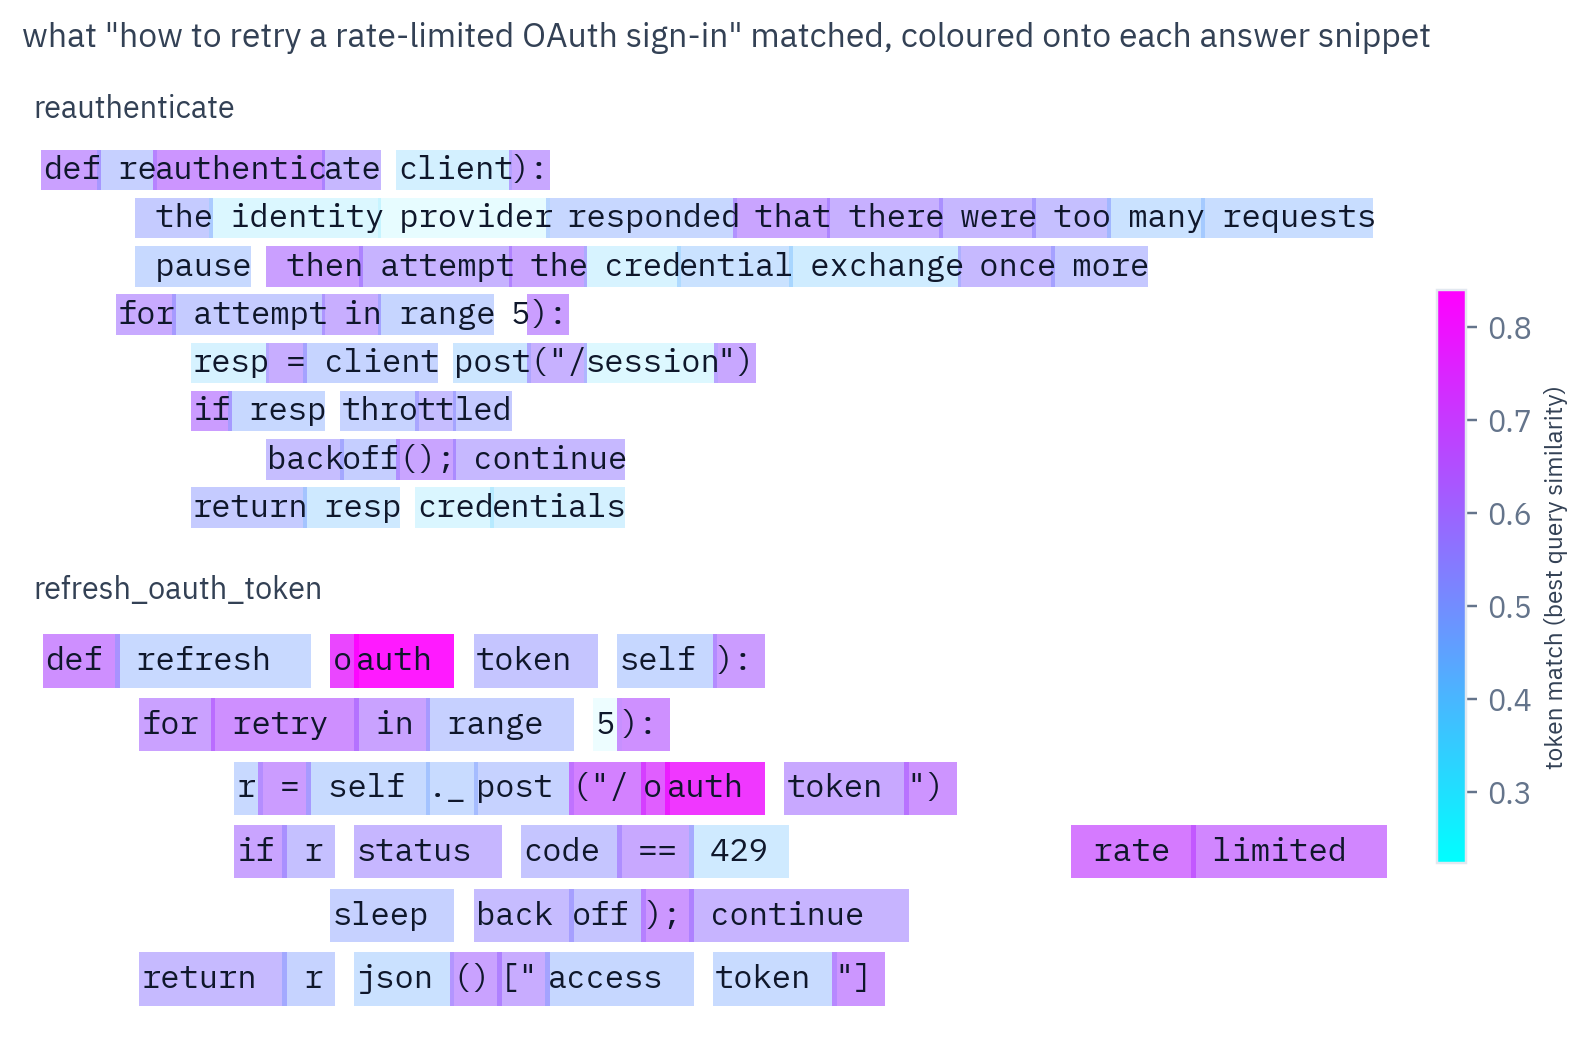

In [10]:
# PyLate document encodings start with two special rows and skip
# punctuation tokens (the model's "skiplist"), so mapping vectors back to source spans takes care.
def token_match(late, query, doc):
    # for each document token span: its best similarity to any query token
    skip = set(late.skiplist)
    query_content = np.asarray(late.encode([query], is_query=True)[0])[2:-1]
    doc_embeddings = np.asarray(late.encode([doc], is_query=False)[0])
    encoded = late.tokenizer(doc, return_offsets_mapping=True, add_special_tokens=True)
    inner = list(zip(encoded["input_ids"][1:-1], encoded["offset_mapping"][1:-1]))
    spans = [span for token_id, span in inner if token_id not in skip][: doc_embeddings.shape[0] - 3]
    intensities = np.clip((query_content @ doc_embeddings[2 : 2 + len(spans)].T).max(0), 0, None)
    return spans, intensities

def highlight_tokens(ax, doc, spans, intensities, lo, hi):
    # render the source with each token's background shaded by its match intensity
    lines = doc.split("\n")
    starts = [0]
    for line in lines:
        starts.append(starts[-1] + len(line) + 1)
    ax.set_xlim(-0.5, max(len(line) for line in lines) + 1)
    ax.set_ylim(-len(lines) + 0.4, 0.7)
    ax.axis("off")
    for (s, e), value in zip(spans, intensities):
        li = doc.count("\n", 0, s)
        col = s - starts[li]
        text = doc[s:e]
        if text.strip():
            normed = min(max((value - lo) / (hi - lo + 1e-9), 0.0), 1.0)
            ax.add_patch(plt.Rectangle((col - 0.1, -li - 0.42), (e - s) + 0.2, 0.84,
                                       color=plt.cm.cool(normed), alpha=normed * 0.9, ec="none", zorder=1))
        ax.text(col, -li, text, family=MONO, fontsize=10.5, va="center", ha="left", color=C["ink"], zorder=2)

data = {name: token_match(late, query, corpus[name]) for name in GOLD}

non_ws = np.array([
    v
    for name, (spans, vals) in data.items()
    for (s, e), v in zip(spans, vals)
    if corpus[name][s:e].strip()
])
lo, hi = float(non_ws.min()), float(non_ws.max())

fig, axes = plt.subplots(len(data), 1, figsize=(8.4, 5.2))
for ax, (name, (spans, vals)) in zip(axes, data.items()):
    highlight_tokens(ax, corpus[name], spans, vals, lo, hi)
    ax.set_title(name, fontsize=10, loc="left")

scale = plt.cm.ScalarMappable(cmap="cool", norm=plt.Normalize(lo, hi))
fig.colorbar(scale, ax=axes, fraction=0.02, pad=0.02).set_label("token match (best query similarity)", fontsize=8)
fig.suptitle('what "' + query + '" matched, coloured onto each answer snippet', fontsize=11)
plt.show()

### 1c · The token-to-token similarity grid

Zooming in on what in the query exactly matched in the documents:

For each query token, LateOn keeps its single best code-token match.

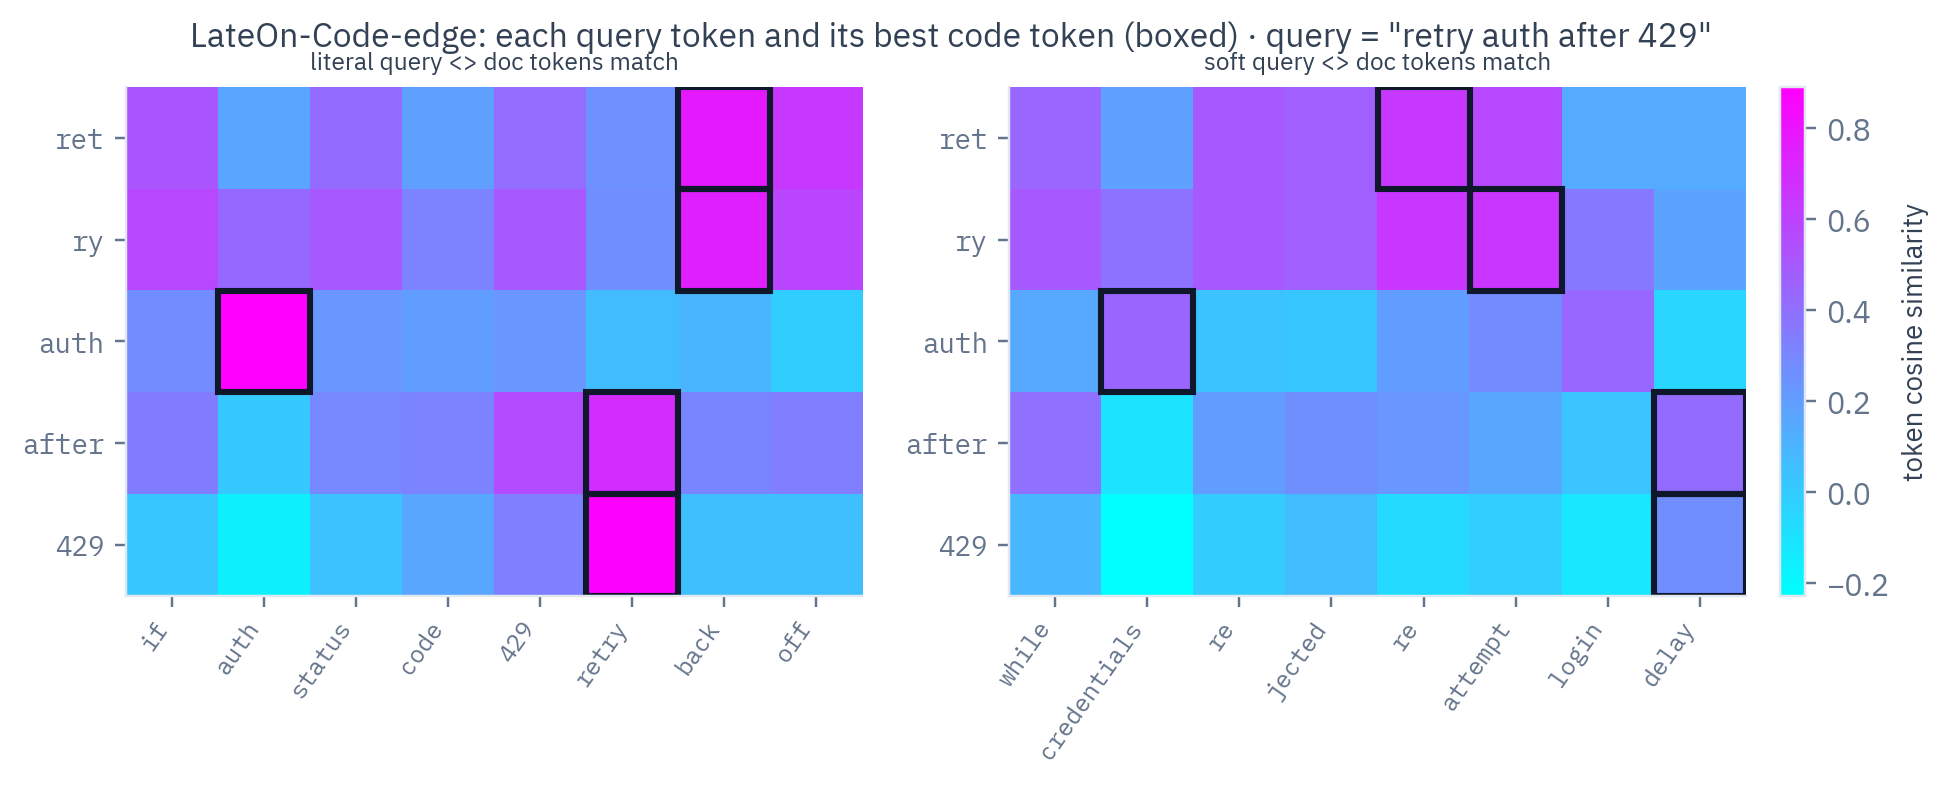

In [11]:
def content_tokens(late, text):
    # readable token labels for the encoding's content rows
    skip = set(late.skiplist)
    ids = late.tokenizer(text, add_special_tokens=True)["input_ids"][1:-1]
    keep = [i for i in ids if i not in skip]
    toks = [late.tokenizer.convert_ids_to_tokens([i])[0].replace("Ġ", "") for i in keep]
    return [tok for tok in toks if tok.isalnum()] # removing punctuation for readability

def heat_matrix(late, query, doc):
    query_embeddings = np.asarray(late.encode([query], is_query=True)[0])
    doc_embeddings = np.asarray(late.encode([doc], is_query=False)[0])
    query_labels = content_tokens(late, query)
    doc_labels = content_tokens(late, doc)
    nq = min(len(query_labels), query_embeddings.shape[0] - 3)
    nd = min(len(doc_labels), doc_embeddings.shape[0] - 3)
    return query_embeddings[2 : 2 + nq] @ doc_embeddings[2 : 2 + nd].T, query_labels[:nq], doc_labels[:nd]

hq = "retry auth after 429"
exact = 'if auth.status_code == 429: retry(backoff)'
soft = 'while credentials_rejected: reattempt_login(delay)'

panels = [
    (*heat_matrix(late, hq, exact), "literal query <> doc tokens match"),
    (*heat_matrix(late, hq, soft), "soft query <> doc tokens match"),
]
vmin = min(panel[0].min() for panel in panels)
vmax = max(panel[0].max() for panel in panels)

fig, axes = plt.subplots(1, 2, figsize=(10, 3),
                         gridspec_kw={"width_ratios": [panels[0][0].shape[1], panels[1][0].shape[1]]})
for ax, (matrix, query_labels, doc_labels, title) in zip(axes, panels):
    image = ax.imshow(matrix, cmap="cool", vmin=vmin, vmax=vmax, aspect="auto")
    ax.grid(False)
    for i in range(matrix.shape[0]):
        ax.add_patch(plt.Rectangle((matrix[i].argmax() - 0.5, i - 0.5), 1, 1, fill=False, ec=C["ink"], lw=2.0))
    ax.set_xticks(range(len(doc_labels)))
    ax.set_xticklabels(doc_labels, rotation=55, ha="right", fontsize=8, **MONOKW)
    ax.set_yticks(range(len(query_labels)))
    ax.set_yticklabels(query_labels, fontsize=9, **MONOKW)
    ax.set_title(title, fontsize=8)

colorbar = fig.colorbar(image, ax=axes, fraction=0.03, pad=0.02)
colorbar.set_label("token cosine similarity", fontsize=9)
fig.suptitle('LateOn-Code-edge: each query token and its best code token (boxed) · query = "' + hq + '"', fontsize=11)
plt.show()

**Left:** `auth` and `429` are exact hits, the symbol survives verbatim.

**Right:** against a synonym snippet, `auth` still reaches `credentials` and `retry` reaches `reattempt`, but `429` finds no good match, because a status code has no synonym -> that is why you want exact **and** soft matching, not one or the other.

Again, we can look why the `Max` in MaxSim is interesting by checking what would happen if we would just average things out (score for 1 query token = mean(sim with each doc token):

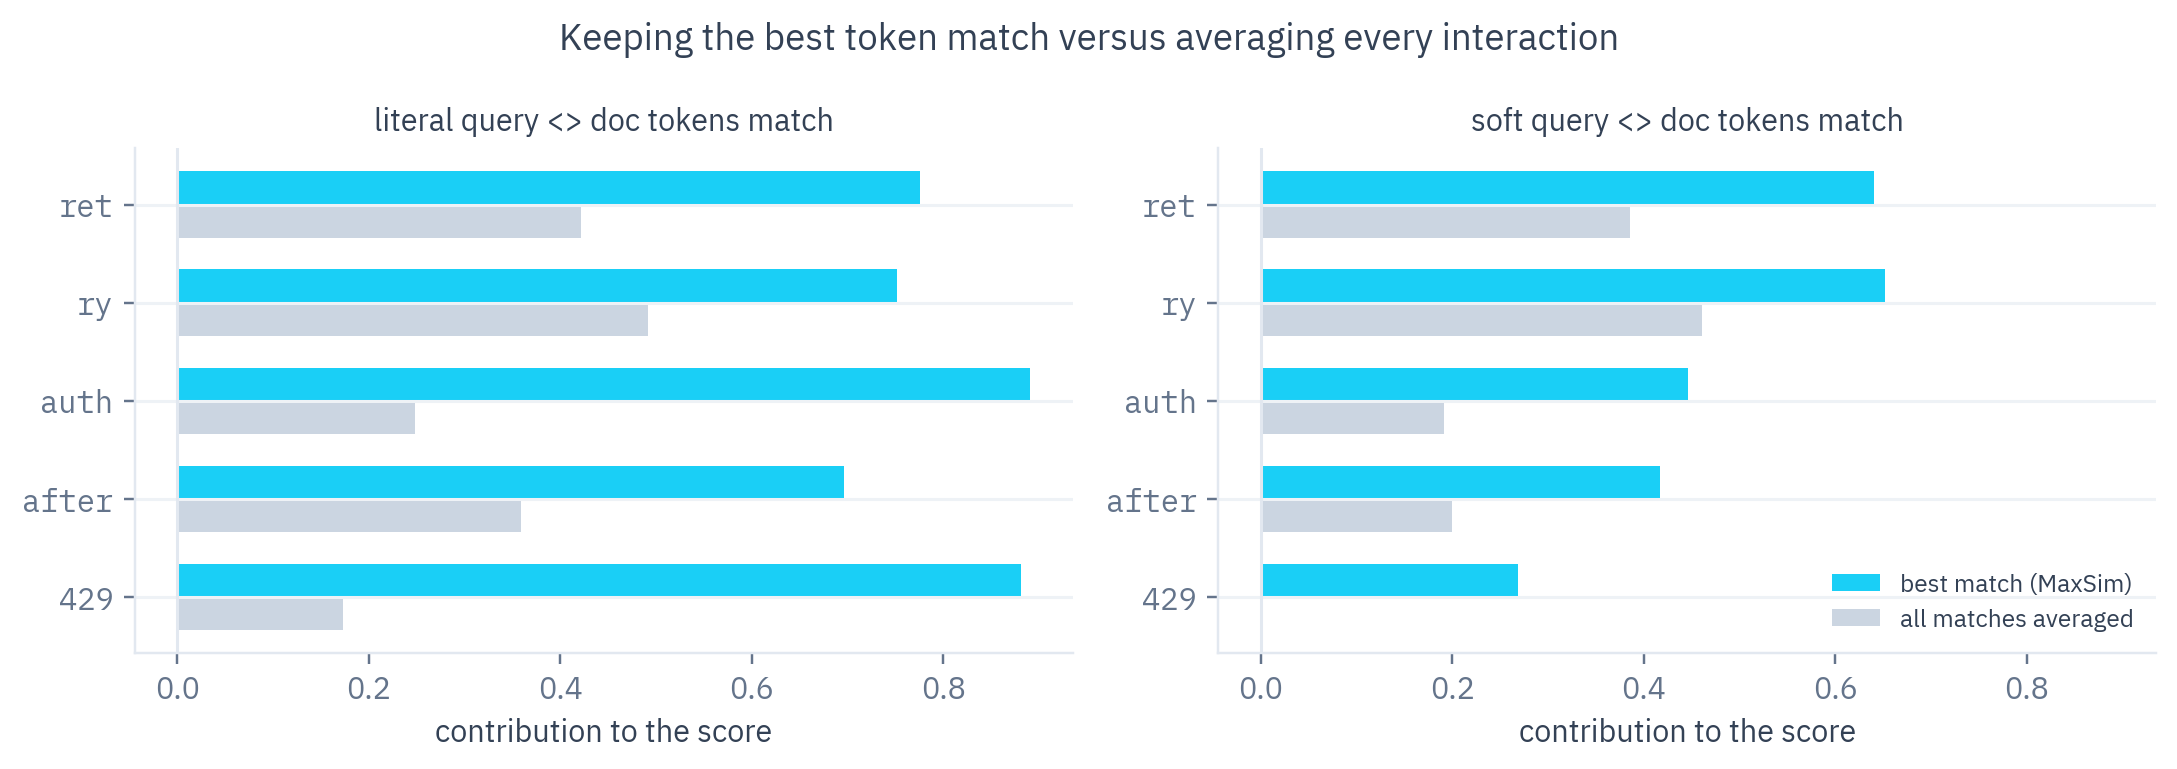

,MaxSim,MeanSim
document,,
literal query <> doc tokens match,3.996,1.693
soft query <> doc tokens match,2.424,1.237


In [12]:
# Counterfactual: what if every document token contributed?
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)

summary = []

for ax, (matrix, query_labels, doc_labels, title) in zip(axes, panels):
    max_contributions = matrix.max(axis=1)
    mean_contributions = matrix.mean(axis=1)

    y = np.arange(len(query_labels))
    height = 0.34

    ax.barh(
        y - height / 2,
        max_contributions,
        height,
        color=C["cyan_fill"],
        label="best match (MaxSim)",
    )
    ax.barh(
        y + height / 2,
        mean_contributions,
        height,
        color=C["baseline"],
        label="all matches averaged",
    )

    ax.axvline(0, color=C["edge"], linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(query_labels, **MONOKW)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("contribution to the score")

    summary.append({
        "document": title,
        "MaxSim": max_contributions.sum(),
        "MeanSim": mean_contributions.sum(),
    })

axes[1].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Keeping the best token match versus averaging every interaction")
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary).set_index("document").round(3))

With MaxSim, an exact clue such as 429 can contribute strongly as soon as one code token matches it. 
If all interactions are averaged, that match is diluted by unrelated tokens and a longer document introduces even more opportunities for dilution.

### 1d · A deterministic MTEB Code comparison

We use the official [MTEB `CodeSearchNetRetrieval`](https://huggingface.co/datasets/mteb/CodeSearchNetRetrieval) task, restricted to its Python subset. The candidate pool is all 1,000 Python functions. To keep the CPU exercise small and reproducible, we sort query ids and take the first 50.

Every query has one annotated function. We report **MRR@10**, **Recall@10**, and **NDCG@10** over the same candidates for BM25, granite, and LateOn.


In [13]:
MTEB_CODE_REVISION = "68e8f0731a656fa4bd5b7c81936d95ad48a39bfe"
N_EVAL_QUERIES = 50

code_corpus = load_dataset(
    "mteb/CodeSearchNetRetrieval", "python-corpus", split="test", revision=MTEB_CODE_REVISION
)
code_queries = load_dataset(
    "mteb/CodeSearchNetRetrieval", "python-queries", split="test", revision=MTEB_CODE_REVISION
)
code_qrels = load_dataset(
    "mteb/CodeSearchNetRetrieval", "python-qrels", split="test", revision=MTEB_CODE_REVISION
)

cdocs = list(code_corpus["text"])
corpus_index = {doc_id: i for i, doc_id in enumerate(code_corpus["id"])}
query_by_id = {str(row["id"]): row["text"].strip() for row in code_queries}
relevant_by_query = {
    str(row["query-id"]): corpus_index[row["corpus-id"]]
    for row in code_qrels
    if row["corpus-id"] in corpus_index and row["score"] > 0
}

selected_ids = sorted(relevant_by_query, key=int)[:N_EVAL_QUERIES]
cqueries = [query_by_id[query_id] for query_id in selected_ids]
cqrels = [{relevant_by_query[query_id]} for query_id in selected_ids]
query_token_counts = [
    len(late.tokenizer(query, add_special_tokens=True, truncation=False)["input_ids"])
    for query in cqueries
]
print(
    f"MTEB Code / Python · {len(cqueries)} fixed queries · {len(cdocs)} candidates · "
    f"query tokens {min(query_token_counts)}–{max(query_token_counts)}"
)

MTEB Code / Python · 50 fixed queries · 1000 candidates · query tokens 6–209


Inspecting 5 queries from the slice:

In [14]:
cards = []
for idx in range(5):
    gold_idx = next(iter(cqrels[idx]))
    cards.append(
        f'<div style="border:1px solid {C["edge"]};border-left:4px solid {C["cyan"]};'
        f'background:{C["signal_bg"]};border-radius:6px;padding:9px 12px;margin:7px 0;">'
        f'<div style="font:600 11px {SANS},sans-serif;color:{C["cyan"]};text-transform:uppercase;'
        f'letter-spacing:.05em;">query id {html.escape(selected_ids[idx])} · '
        f'{query_token_counts[idx]} tokens</div>'
        f'<div style="margin:5px 0 8px;color:{C["ink"]};">{html.escape(cqueries[idx])}</div>'
        f'<pre style="margin:0;font:12px/1.45 {MONO},monospace;color:{C["ink"]};white-space:pre-wrap;">'
        f'{html.escape(cdocs[gold_idx][:700])}</pre></div>'
    )
display(HTML("".join(cards)))

In [15]:
t = time.time()
bm25 = BM25Okapi([toks(doc) for doc in cdocs])
bm25_rank = [np.argsort(bm25.get_scores(toks(query)))[::-1] for query in cqueries]

DD = dense.encode(cdocs, normalize_embeddings=True, batch_size=32, show_progress_bar=True)
QD = dense.encode(cqueries, normalize_embeddings=True, batch_size=32, show_progress_bar=False)
dense_rank = [np.argsort(QD[i] @ DD.T)[::-1] for i in range(len(cqueries))]

DE = [np.asarray(doc) for doc in late.encode(cdocs, is_query=False, batch_size=16, show_progress_bar=True)]
QE = [np.asarray(query) for query in late.encode(cqueries, is_query=True, batch_size=16, show_progress_bar=False)]
late_rank = [
    np.argsort([maxsim(query, doc) for doc in DE])[::-1]
    for query in tqdm(QE, desc="LateOn MaxSim")
]
print(f"indexed and ranked all three ways in {time.time() - t:.0f}s on CPU")

def metrics_at(rankings, qrels, k=10):
    positions = [
        next((i for i, doc in enumerate(ranked) if doc in relevant), np.inf)
        for ranked, relevant in zip(rankings, qrels)
    ]
    return {
        f"MRR@{k}": np.mean([1 / (rank + 1) if rank < k else 0 for rank in positions]),
        f"Recall@{k}": np.mean([rank < k for rank in positions]),
        f"NDCG@{k}": np.mean([1 / math.log2(rank + 2) if rank < k else 0 for rank in positions]),
    }

code_eval = pd.DataFrame({
    "BM25 (lexical)": metrics_at(bm25_rank, cqrels),
    "granite (dense)": metrics_at(dense_rank, cqrels),
    "LateOn (multi-vector)": metrics_at(late_rank, cqrels),
}).T.round(3)
display(code_eval)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding documents (bs=16):   0%|          | 0/63 [00:00<?, ?it/s]

LateOn MaxSim:   0%|          | 0/50 [00:00<?, ?it/s]

indexed and ranked all three ways in 37s on CPU


,MRR@10,Recall@10,NDCG@10
BM25 (lexical),0.490,0.68,0.537
granite (dense),0.771,0.98,0.823
LateOn (multi-vector),0.900,1.00,0.926


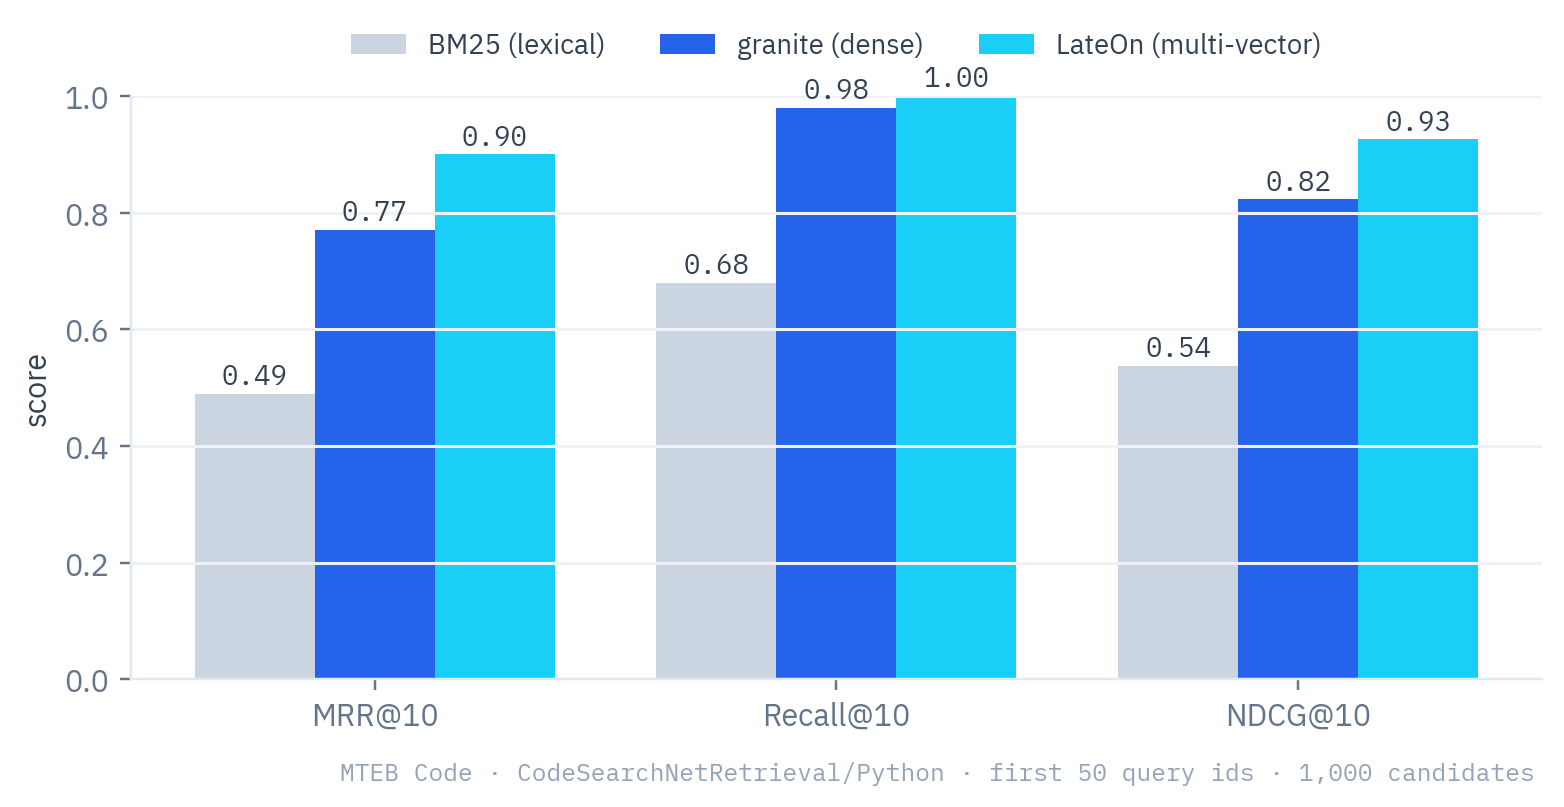

In [16]:
metrics = ["MRR@10", "Recall@10", "NDCG@10"]
colors = {"BM25 (lexical)": C["baseline"], "granite (dense)": C["blue"], "LateOn (multi-vector)": C["cyan_fill"]}
x, width = np.arange(len(metrics)), 0.26

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for i, (name, color) in enumerate(colors.items()):
    vals = [code_eval.loc[name, metric] for metric in metrics]
    bars = ax.bar(x + (i - 1) * width, vals, width, color=color, label=name)
    for bar, value in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.006, f"{value:.2f}",
                ha="center", va="bottom", fontsize=9, color=C["text"], **MONOKW)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02))
ax.text(
    0.995, -0.14,
    f"MTEB Code · CodeSearchNetRetrieval/Python · first {len(cqueries)} query ids · 1,000 candidates",
    transform=ax.transAxes, ha="right", va="top", fontsize=8, color=C["faint"], **MONOKW,
)
plt.tight_layout()
plt.show()

**Takeaway:** this is a small eval, not a replacement for the full MTEB Code leaderboard!

But even on this small eval, we can see that:
- Both granite and LateOn have a clear advantage over BM25!
- While this tiny benchmark is close to saturation in terms of Recall@10, LateOn's rankings (which are expressed through MRR and NDCG) are of higher quality.

## 2 · Field case: multimodal retrieval

Code makes *granularity* obvious. Visual documents make *representation loss* obvious: a page is many regions, a title, a table, a chart and a legend.

We ask two separate questions:

1. **Retrieval:** which page ranks highest in the same 13-page pool?
2. **Answerability:** after parsing, did the representation preserve the binding between labels, values and visual regions?

The pages and original queries come from the [ViDoRe v3 benchmark](https://huggingface.co/datasets/vidore/vidore_v3_pharmaceuticals). The source documents contain many domain abbreviations, but those abbreviations are not concepts you need to memorize. We will refer to the cases by the retrieval problem they illustrate:

| Case | Original benchmark question | Why it is here |
|---|---|---|
| **Exact value in a chart** | "ANDA tentative approvals by the FDA in FY2012" | Can a representation keep the year, series and value `102` bound together? |
| **Trend with a plausible distractor** | "Is there a rise in CDER NME submissions from 2007 to 2008?" | Can retrieval distinguish visually similar regulatory charts? |
| **Geographic pattern** | "Is there uniform interest across all EU regions in adopting Individual Learning Accounts according to the 2024 report?" | Can text preserve an answer expressed through colours and locations on a map? |

(for reference, if you're curious: ANDA means *Abbreviated New Drug Application*, CDER is the *Center for Drug Evaluation and Research*, NME means *new molecular entity*, and ILA means *Individual Learning Account*)

We work through the exact-value case first, then use the trend and map cases as stress tests.

In [17]:
REVISIONS = {
    "vidore_pharma": "3abd4aa8a9445fb5538a78a19ba50bd57bd22b5c",
    "vidore_hr": "0cdf0979f2c5a0fd3e335e6373b9da48a9fe3bc3",
}
VIDORE = f"https://huggingface.co/datasets/vidore/vidore_v3_pharmaceuticals/resolve/{REVISIONS['vidore_pharma']}/pdfs/"
ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True)

def fetch(remote_name, local_name, base=VIDORE):
    path = ASSETS / local_name
    if not path.exists():
        urllib.request.urlretrieve(base + remote_name, path)
    print(f"{local_name}: {path.stat().st_size / 1e6:.1f} MB")
    return path

GENERIC_DRUG_DOC_ID = "FDA_Office_of_Generic_Drugs_OGD_Keynote_Address_GDUFA_Past_Present_and_Future"
OPIOID_DOC_ID = "Presentation_FDAs_Role_in_Confronting_the_Opioid_Epidemic"
GENERIC_DRUG_REPORT = fetch(GENERIC_DRUG_DOC_ID + ".pdf", "fda_gdufa_keynote.pdf")
OPIOID_REPORT = fetch(OPIOID_DOC_ID + ".pdf", "fda_opioid_epidemic.pdf")

HR_BASE = f"https://huggingface.co/datasets/vidore/vidore_v3_hr/resolve/{REVISIONS['vidore_hr']}/pdfs/"

NEW_DRUG_DOC_ID = "CDER_New_Drugs_Program_2019_Update"
EU_EMPLOYMENT_DOC_ID = "european_network_of_public_employment_services_annual-KE0124024ENN"
NEW_DRUG_REPORT = fetch(NEW_DRUG_DOC_ID + ".pdf", "cder_new_drugs_2019.pdf")
EU_EMPLOYMENT_REPORT = fetch(EU_EMPLOYMENT_DOC_ID + ".pdf", "eu_pes_annual_report.pdf", base=HR_BASE)

def render_page(pdf_path, page_idx, dpi=110):
    with fitz.open(pdf_path) as document:
        pix = document[page_idx].get_pixmap(dpi=dpi)
    return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

CASE_LABELS = {
    "value": "Exact value in a chart",
    "trend": "Trend with a plausible distractor",
    "map": "Geographic pattern",
}
visual_queries = {
    "value": "ANDA tentative approvals by the FDA in FY2012",
    "trend": "Is there a rise in CDER NME submissions from 2007 to 2008?",
    "map": "Is there uniform interest across all EU regions in adopting Individual Learning Accounts according to the 2024 report?",
}
page = render_page(GENERIC_DRUG_REPORT, 11)

fda_gdufa_keynote.pdf: 0.5 MB
fda_opioid_epidemic.pdf: 0.8 MB
cder_new_drugs_2019.pdf: 1.4 MB
eu_pes_annual_report.pdf: 6.0 MB


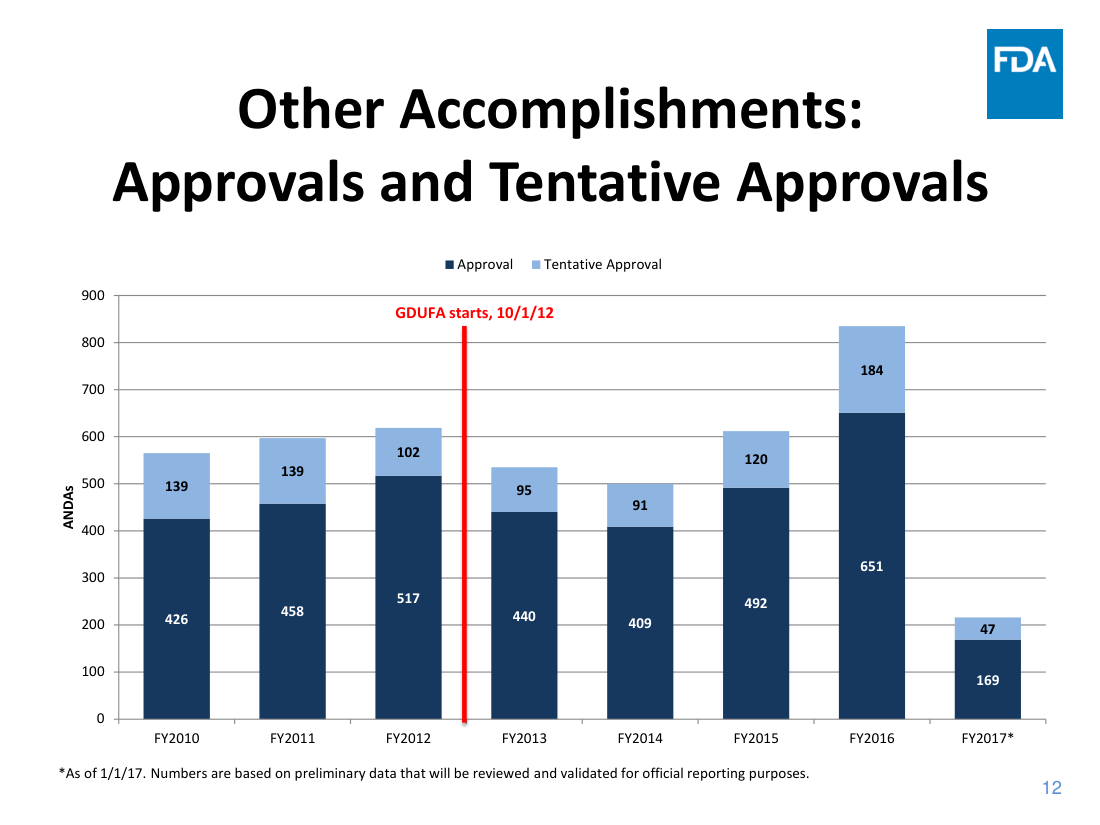

In [18]:
page

### 2a · Representation A: parsed Markdown

Parsing is more than extracting words: a useful parser must reconstruct **reading order, headings, tables and relationships between labels and values**. When that layout survives as structured Markdown, ordinary text retrieval and language models can use the page without having to reason over pixels.

The pinned ViDoRe Markdown keeps the default run deterministic. It also gives us a useful lower-bound example: the words may survive even when some of the page structure does not.

In [19]:
CORPUS_SPECS = {
    "pharma": {
        "repo": "vidore/vidore_v3_pharmaceuticals",
        "revision": REVISIONS["vidore_pharma"],
        "files": ["corpus/test-00000-of-00002.parquet", "corpus/test-00001-of-00002.parquet"],
    },
    "hr": {
        "repo": "vidore/vidore_v3_hr",
        "revision": REVISIONS["vidore_hr"],
        "files": ["corpus/test-00000-of-00001.parquet"],
    },
}
_parsed_corpora = {}

def parsed_corpus(dataset_key):
    if dataset_key not in _parsed_corpora:
        spec = CORPUS_SPECS[dataset_key]
        frames = []
        for filename in spec["files"]:
            path = hf_hub_download(
                repo_id=spec["repo"], repo_type="dataset", filename=filename, revision=spec["revision"]
            )
            frames.append(pd.read_parquet(path, columns=["doc_id", "page_number_in_doc", "markdown"]))
        _parsed_corpora[dataset_key] = pd.concat(frames, ignore_index=True)
    return _parsed_corpora[dataset_key]

def vidore_parsed_text(dataset_key, doc_id, page_idx):
    corpus = parsed_corpus(dataset_key)
    rows = corpus[(corpus.doc_id == doc_id) & (corpus.page_number_in_doc == page_idx)]
    if len(rows) != 1:
        raise ValueError(f"Expected one parsed page for {doc_id} p{page_idx + 1}; found {len(rows)}")
    return str(rows.iloc[0].markdown)

print(vidore_parsed_text("pharma", GENERIC_DRUG_DOC_ID, 11))


Other Accomplishments: Approvals and Tentative Approvals
FY2010 FY2011 FY2012 FY2013 FY2014 FY2015 FY2016 FY2017* 12
ANDAs
0 100 200 300 400 500 600 700 800 900
Approval Tentative Approval
184 102 120 139 139 95 91 651 517 492 458 440 426 409 47 169
FDA GDUFA starts, 10/1/12
*As of 1/1/17. Numbers are based on preliminary data that will be reviewed and validated for official reporting purposes.


#### Optional: parse the page live with LightOn `/parse`

[LightOn Parse](https://developers.lighton.ai/api-reference/parse/parse-a-document-to-markdown) is useful here because it returns structured Markdown rather than a flat OCR transcript. Preserving headings and table layout keeps facts attached to their context; for example, `102` should remain tied to *tentative approvals* and *FY2012*, not become an isolated number in a bag of text.

Set `LIGHTON_API_KEY` to use the live parser in the page gallery, and have a fairer comparison! Without it, the notebook falls back to the pinned ViDoRe Markdown and makes no API call.

In [20]:
LIGHTON_KEY = os.environ.get("LIGHTON_API_KEY")

def parse_page_with_lighton(pdf_path, page_idx):
    with fitz.open(pdf_path) as source, fitz.open() as one_page:
        one_page.insert_pdf(source, from_page=page_idx, to_page=page_idx)
        pdf_bytes = one_page.tobytes()

    response = requests.post(
        "https://api.lighton.ai/api/v3/parse",
        headers={"Authorization": f"Bearer {LIGHTON_KEY}"},
        files={"file": ("page.pdf", pdf_bytes, "application/pdf")},
        timeout=120,
    )
    response.raise_for_status()
    return response.json()["result"]["pages"][0]["markdown"]

if LIGHTON_KEY:
    print("Live LightOn parsing enabled for the source-page gallery.")
else:
    print("Live parsing is off; using pinned ViDoRe Markdown.")

Live LightOn parsing enabled for the source-page gallery.


The pinned Markdown keeps the number `102`, but flattens the chart enough that its year-to-series-to-value binding is no longer explicit. That is not an argument that parsing must lose layout: in fact, parsing with a stronger parser like LightOn actually preserves it much better; but this is a demonstration that **parser quality changes answerability**!

A layout-preserving parse can close much of this gap by reconstructing the chart as a table: we retain text-native search and readable context while keeping the relationships required to answer the question.

### 2b · Representation B: visual late interaction

We use `colSmol-256M`, a ColPali-family visual retrieval model. It embeds each page image as many vectors. We rank the three original ViDoRe queries over the same 13-page pool, then compare those rankings with parsed Markdown + BM25.


As we wrote about, the pool contains three cases with different kinds of evidence:

1. **Exact value in a chart:** one page is judged relevant. The answer depends on binding FY2012 to the tentative-approval light-blue bar, and its value, `102`.
2. **Trend with a plausible distractor:** two pages are judged relevant in the ViDoRe benchmark. Other FDA charts contain similar years, terms and bar shapes, so this is a difficult retrieval case.
3. **Geographic pattern:** a policy paragraph and its companion map are judged relevant. The answer is “no,” and the decisive evidence is the distribution of colours across the map.

The gallery below shows the value chart, the clearest new-drug chart for the trend case, then the policy context and map for the geographic case. The full pool, including every benchmark-relevant page and the distractors, is ranked afterward.

Let's start by viewing those pages:


In [21]:
t = time.time()
col_base = ColIdefics3.from_pretrained(
    "vidore/ColSmolVLM-Instruct-256M-base",
    torch_dtype=torch.float32,
    device_map="cpu",
    attn_implementation="eager",
)
col = PeftModel.from_pretrained(col_base, snapshot_download("vidore/colSmol-256M")).eval()
colp = ColIdefics3Processor.from_pretrained("vidore/colSmol-256M")

pool_records = [
    {"dataset": "pharma", "pdf": GENERIC_DRUG_REPORT, "doc_id": GENERIC_DRUG_DOC_ID, "page_idx": 11, "label": "FDA generic-drug deck p12 · approval counts [relevant: value]"},
    {"dataset": "pharma", "pdf": GENERIC_DRUG_REPORT, "doc_id": GENERIC_DRUG_DOC_ID, "page_idx": 15, "label": "FDA generic-drug deck p16"},
    {"dataset": "pharma", "pdf": GENERIC_DRUG_REPORT, "doc_id": GENERIC_DRUG_DOC_ID, "page_idx": 26, "label": "FDA generic-drug deck p27 · approval-rate chart"},
    {"dataset": "pharma", "pdf": GENERIC_DRUG_REPORT, "doc_id": GENERIC_DRUG_DOC_ID, "page_idx": 33, "label": "FDA generic-drug deck p34"},
    {"dataset": "pharma", "pdf": OPIOID_REPORT, "doc_id": OPIOID_DOC_ID, "page_idx": 3, "label": "FDA opioid deck p4"},
    {"dataset": "pharma", "pdf": OPIOID_REPORT, "doc_id": OPIOID_DOC_ID, "page_idx": 13, "label": "FDA opioid deck p14"},
    {"dataset": "pharma", "pdf": NEW_DRUG_REPORT, "doc_id": NEW_DRUG_DOC_ID, "page_idx": 7, "label": "FDA new-drug deck p8 · actions and approvals [relevant: trend]"},
    {"dataset": "pharma", "pdf": NEW_DRUG_REPORT, "doc_id": NEW_DRUG_DOC_ID, "page_idx": 10, "label": "FDA new-drug deck p11 · orphan-drug approvals [relevant: trend]"},
    {"dataset": "pharma", "pdf": NEW_DRUG_REPORT, "doc_id": NEW_DRUG_DOC_ID, "page_idx": 3, "label": "FDA new-drug deck p4 · cohort curves"},
    {"dataset": "pharma", "pdf": NEW_DRUG_REPORT, "doc_id": NEW_DRUG_DOC_ID, "page_idx": 12, "label": "FDA new-drug deck p13 · FY2019 approvals table"},
    {"dataset": "hr", "pdf": EU_EMPLOYMENT_REPORT, "doc_id": EU_EMPLOYMENT_DOC_ID, "page_idx": 10, "label": "EU employment report p11 · account policy context [relevant: map]"},
    {"dataset": "hr", "pdf": EU_EMPLOYMENT_REPORT, "doc_id": EU_EMPLOYMENT_DOC_ID, "page_idx": 11, "label": "EU employment report p12 · account adoption map [relevant: map]"},
    {"dataset": "hr", "pdf": EU_EMPLOYMENT_REPORT, "doc_id": EU_EMPLOYMENT_DOC_ID, "page_idx": 14, "label": "EU employment report p15"},
]
pool_pages = [render_page(item["pdf"], item["page_idx"]) for item in pool_records]
with torch.no_grad():
    pool_embeddings = [
        col(**colp.process_images([image]))[0]
        for image in tqdm(pool_pages, desc="embedding pages")
    ]
print(f"loaded colSmol-256M and embedded {len(pool_pages)} pages in {time.time() - t:.0f}s")

embedding pages:   0%|          | 0/13 [00:00<?, ?it/s]

loaded colSmol-256M and embedded 13 pages in 60s


In [22]:
from colpali_engine.interpretability import plot_similarity_map

def clean(token):
    return token.replace("Ġ", "").replace("Ċ", "")

def pick_token(tokens, word):
    for i, token in enumerate(tokens):
        piece = clean(token).lower()
        if len(piece) > 2 and (piece in word.lower() or word.lower() in piece):
            return i
    raise ValueError(f"No token overlaps {word!r}")

def similarity_maps(page_index, query):
    image_batch = colp.process_images([pool_pages[page_index]])
    with torch.no_grad():
        query_embedding = col(**colp.process_queries([query]))[0]

    image_rows = pool_embeddings[page_index][colp.get_image_mask(image_batch)[0]]
    side = math.isqrt(colp.image_seq_len)
    maps = (query_embedding @ image_rows[-colp.image_seq_len:].T).reshape(len(query_embedding), side, side)
    tokens = colp.tokenizer.convert_ids_to_tokens(colp.process_queries([query])["input_ids"][0].tolist())
    return maps, tokens

def image_png(image):
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return buffer.getvalue()

def similarity_png(image, similarity_map, value_range, title):
    fig, ax = plot_similarity_map(image=image, similarity_map=similarity_map, normalization_range=value_range)
    ax.set_title(title, fontsize=10)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return buffer.getvalue()

def show_carousel(slides):
    selector = widgets.SelectionSlider(
        options=[(f"{i + 1}/{len(slides)} · {slide['title']}", i) for i, slide in enumerate(slides)],
        layout=widgets.Layout(width="100%"), continuous_update=False,
    )
    output = widgets.Output()

    def render(*_):
        slide = slides[selector.value]
        image = widgets.Image(
            value=slide["image"], format="png",
            layout=widgets.Layout(width="50%" if "markdown" in slide else "100%", height="520px", object_fit="contain"),
        )
        body = [image]
        if "markdown" in slide:
            body.append(widgets.HTML(
                value=(
                    f'<strong>{html.escape(slide["parse_source"])}</strong>'
                    f'<pre style="white-space:pre-wrap;font:12px/1.5 {MONO},monospace">'
                    f'{html.escape(slide["markdown"])}</pre>'
                ),
                layout=widgets.Layout(width="50%", height="520px", overflow="auto", padding="12px"),
            ))
        caption = widgets.HTML(f'<b>{html.escape(slide["title"])}</b><br>{html.escape(slide["note"])}')
        with output:
            clear_output(wait=True)
            display(widgets.VBox([widgets.HBox(body), caption]))

    selector.observe(render, names="value")
    render()
    display(widgets.VBox([selector, output]))

In [23]:
def parsed_page(item):
    if LIGHTON_KEY:
        try:
            return parse_page_with_lighton(item["pdf"], item["page_idx"]), "LightOn layout-preserving parse"
        except (requests.RequestException, KeyError) as error:
            print(f"LightOn parse unavailable for {item['label']}: {error}; using ViDoRe Markdown.")
    return vidore_parsed_text(item["dataset"], item["doc_id"], item["page_idx"]), "Pinned ViDoRe Markdown"

source_pages = []
for page_index, case_key in [(0, "value"), (6, "trend"), (10, "map"), (11, "map")]:
    item = pool_records[page_index]
    markdown, parse_source = parsed_page(item)
    source_pages.append({
        "title": item["label"].split(" [relevant:")[0],
        "note": f"{CASE_LABELS[case_key]} | Original query: {visual_queries[case_key]}",
        "image": image_png(pool_pages[page_index]),
        "markdown": markdown,
        "parse_source": parse_source,
    })

show_carousel(source_pages)

In [24]:
pool_labels = [item["label"] for item in pool_records]
visual_orders = {}

for case_key, query_text in visual_queries.items():
    with torch.no_grad():
        query_embedding = col(**colp.process_queries([query_text]))
    scores = colp.score_multi_vector(query_embedding, pool_embeddings)[0]
    order = torch.argsort(scores, descending=True).tolist()
    visual_orders[case_key] = order

    print(CASE_LABELS[case_key])
    print(f'Original benchmark query: "{query_text}"')
    for rank, idx in enumerate(order[:5], start=1):
        print(f"   {rank}. {pool_labels[idx]:48s} MaxSim = {scores[idx]:.2f}")
    print()

Exact value in a chart
Original benchmark query: "ANDA tentative approvals by the FDA in FY2012"
   1. FDA generic-drug deck p12 · approval counts [relevant: value] MaxSim = 17.49
   2. FDA generic-drug deck p16                        MaxSim = 17.25
   3. FDA new-drug deck p8 · actions and approvals [relevant: trend] MaxSim = 15.64
   4. FDA new-drug deck p13 · FY2019 approvals table   MaxSim = 15.36
   5. FDA new-drug deck p11 · orphan-drug approvals [relevant: trend] MaxSim = 15.34

Trend with a plausible distractor
Original benchmark query: "Is there a rise in CDER NME submissions from 2007 to 2008?"
   1. FDA generic-drug deck p27 · approval-rate chart  MaxSim = 19.56
   2. FDA new-drug deck p11 · orphan-drug approvals [relevant: trend] MaxSim = 18.55
   3. FDA new-drug deck p8 · actions and approvals [relevant: trend] MaxSim = 17.27
   4. FDA new-drug deck p4 · cohort curves             MaxSim = 16.40
   5. FDA generic-drug deck p16                        MaxSim = 15.50

Geographi

**Visual ranking observations:**

1. **Exact value in a chart:** the page judged relevant ranks first.
2. **Geographic pattern:** the policy paragraph and its companion map rank first and second.
3. **Trend with a plausible distractor:** the two pages judged relevant by ViDoRe rank second and third. Another FDA chart ranks first because it contains similar terms, years and bar shapes.

#### Similarity maps

The token-level similarity maps let us inspect what the visual retriever matched.

They show which global-view patches are most similar to a query token. They are **not causal explanations**, and the model also scores local crops that are not shown in this coarse global view.

We visualize the value and map cases because their expected evidence is easy to locate on the page. The trend case is deliberately left to the ranking comparison, where its ambiguity is the point.


In [25]:
token_matches = []
for case_key, page_index, words in [
    ("value", 0, ["tentative", "approvals"]),
    ("map", 11, ["Learning", "regions"]),
]:
    maps, tokens = similarity_maps(page_index, visual_queries[case_key])
    token_ids = [pick_token(tokens, word) for word in words]
    value_range = (float(maps[token_ids].min()), float(maps[token_ids].max()))

    for token_id in token_ids:
        token = clean(tokens[token_id])
        token_matches.append({
            "title": f'{CASE_LABELS[case_key]} · token “{token}”',
            "note": f"shared colour range for this case · max similarity {float(maps[token_id].max()):.2f}",
            "image": similarity_png(pool_pages[page_index], maps[token_id], value_range, f'query token “{token}”'),
        })

show_carousel(token_matches)

### 2c · Same 13 pages, pinned Markdown + BM25

This is like-for-like: the same three original benchmark queries and the same 13 pages, using the Markdown shipped by the ViDoRe datasets. The table uses the plain-language case names introduced above.

In [26]:
parsed_pool = [
    vidore_parsed_text(item["dataset"], item["doc_id"], item["page_idx"])
    for item in pool_records
]
parsed_bm25 = BM25Okapi([toks(text) for text in parsed_pool])
STOP = {"a", "all", "according", "across", "by", "from", "in", "is", "the", "there", "to"}

comparison_rows = []
for case_key, query_text in visual_queries.items():
    bm25_scores = parsed_bm25.get_scores(toks(query_text))
    bm25_order = np.argsort(bm25_scores)[::-1]
    for rank in range(5):
        bidx, vidx = int(bm25_order[rank]), int(visual_orders[case_key][rank])
        overlap = sorted((set(toks(query_text)) & set(toks(parsed_pool[bidx]))) - STOP)
        comparison_rows.append({
            "case": CASE_LABELS[case_key],
            "rank": rank + 1,
            "parsed Markdown + BM25": pool_labels[bidx],
            "query terms found": ", ".join(overlap),
            "visual MaxSim": pool_labels[vidx],
        })

comparison = pd.DataFrame(comparison_rows)
display(comparison.set_index(["case", "rank"]))

parsed Markdown + BM25  \
case                              rank                                                      
Exact value in a chart            1                             FDA generic-drug deck p16   
                                  2     FDA generic-drug deck p12 · approval counts [r...   
                                  3        FDA new-drug deck p13 · FY2019 approvals table   
                                  4       FDA generic-drug deck p27 · approval-rate chart   
                                  5                              EU employment report p15   
Trend with a plausible distractor 1       FDA generic-drug deck p27 · approval-rate chart   
                                  2        FDA new-drug deck p13 · FY2019 approvals table   
                                  3     FDA new-drug deck p8 · actions and approvals [...   
                                  4                              EU employment report p15   
                                  5     FDA new-drug deck p11 · orphan-drug approvals ...   
Geographic pattern                1     EU employment report p12 · account adoption ma...   
                                  2     EU employment report p11 · account policy cont...   
                                  3                              EU employment report p15   
                                  4        FDA new-drug deck p13 · FY2019 approvals table   
                                  5       FDA generic-drug deck p27 · approval-rate chart   

                                                                   query terms found  \
case                              rank                                                 
Exact value in a chart            1          anda, approvals, fda, fy2012, tentative   
                                  2                approvals, fda, fy2012, tentative   
                                  3                                   approvals, fda   
                                  4                                   approvals, fda   
                                  5                                                    
Trend with a plausible distractor 1                            2007, 2008, cder, nme   
                                  2                                 nme, submissions   
                                  3                     2007, 2008, nme, submissions   
                                  4                                                    
                                  5                                 2007, 2008, cder   
Geographic pattern                1     2024, accounts, individual, learning, report   
                                  2     2024, accounts, individual, learning, report   
                                  3                                 2024, eu, report   
                                  4                                                    
                                  5                                                    

                                                                            visual MaxSim  
case                              rank                                                     
Exact value in a chart            1     FDA generic-drug deck p12 · approval counts [r...  
                                  2                             FDA generic-drug deck p16  
                                  3     FDA new-drug deck p8 · actions and approvals [...  
                                  4        FDA new-drug deck p13 · FY2019 approvals table  
                                  5     FDA new-drug deck p11 · orphan-drug approvals ...  
Trend with a plausible distractor 1       FDA generic-drug deck p27 · approval-rate chart  
                                  2     FDA new-drug deck p11 · orphan-drug approvals ...  
                                  3     FDA new-drug deck p8 · actions and approvals [...  
                                  4                  FDA new-drug de

**What the comparison actually shows:**

- **Exact value in a chart:** BM25 can retrieve the right subject because the labels and `102` survive, but the pinned Markdown loses the year-to-series-to-value binding. A layout-preserving LightOn parse can reconstruct that chart as structured Markdown and keep the answer text-native.
- **Trend with a plausible distractor:** both approaches prefer the same plausible distractor. Neither parsing nor vision is magic. Similar terms, years and chart shapes still require evaluation against real relevance judgments. The two pages judged relevant by ViDoRe rank higher with visual MaxSim.
- **Geographic pattern:** pinned Markdown retrieves both relevant pages, but the decisive evidence is a spatial colour distribution rather than a sentence. Some answers genuinely remain visual.

**Takeaway:** the choice is not simply “text or vision.” Start with high-quality, layout-preserving parsing because it produces searchable, readable and LLM-friendly structure at low downstream complexity. Keep visual late interaction for pages where the evidence cannot be faithfully expressed as text: maps, diagrams, or charts whose spatial form is itself the answer.

## Wrap-up

1. **The bottleneck:** one vector is the wrong shape when a query carries many independent clues.
2. **MaxSim:** keep a vector per token or patch, let every query token find its best local match, and sum the winners.
3. **Code:** late interaction keeps exact symbols and soft semantic matches visible; the mini MTEB Code eval illustrates its strength.
4. **Visual documents:** layout-preserving parsing should be the first text-native representation; visual retrieval remains valuable when spatial structure itself carries the answer.

Late interaction is not free. The point of the field guide is to make the trade visible enough to measure on your own queries, documents and hardware!

**Pointers:** [PyLate](https://github.com/lightonai/pylate), [`lightonai/LateOn-Code-edge`](https://huggingface.co/lightonai/LateOn-Code-edge), [MTEB `CodeSearchNetRetrieval`](https://huggingface.co/datasets/mteb/CodeSearchNetRetrieval), [`vidore/colSmol-256M`](https://huggingface.co/vidore/colSmol-256M), [ViDoRe v3](https://huggingface.co/datasets/vidore/vidore_v3_pharmaceuticals), [LightOn Console](https://developers.lighton.ai/), and the [companion lecture deck](https://docs.google.com/presentation/d/15mTKxaVCpWEGt5zp8OnBeXnSvkdmQgz4raiyWv7E9Rc/edit?usp=sharing).